# 0.4 — Fractions, Ratios & Percentages, at the computer

Do the **pen-and-paper worksheet first**. Here Python referees your fraction work with
*exact* arithmetic, you write the most common line in ML data-prep, and infinity makes a
surprise appearance.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction     # exact fractions — no decimal fuzz, ever

## 1. The exact-fraction referee

`Fraction(3, 4)` *is* $\frac{3}{4}$ — Python keeps it as a fraction and plays by the exact
rules you used on paper, including automatic simplification.

In [2]:
print(Fraction(18, 24))                          # worksheet problem 3 — auto-simplified
print(Fraction(2, 3) * Fraction(9, 10))          # problem 5
print(Fraction(3, 4) / Fraction(1, 2))           # problem 6
print(Fraction(1, 4) + Fraction(2, 3))           # problem 7 — common denominator, handled

3/4
3/5
3/2
11/12


In [3]:
# YOUR TURN — referee the rest of your paper work.

print(Fraction(5, 6) - Fraction(1, 2))    # problem 8 — matches your answer?

# P11: does Fraction(12, 20) simplify to YOUR x/5?
# P15: the jacket. Compute 0.70 * 1.10 and 1.10 * 0.70 — does order matter?
# P17: overall pass rate: (15 + 44) correct out of (20 + 80) — as a Fraction

1/3


## 2. The most common line in ML data-prep

*Divide everything by the total* → the results always sum to 1 → you've made a
**probability distribution**. You proved why on paper (problem 16); now type the line
you'll use for years.

In [4]:
scores = [6, 10, 4]                          # worksheet problem 10
props = [s / sum(scores) for s in scores]    # THE line: each score over the total
print(props, "sum:", sum(props))

# YOUR TURN: make up 5 scores of your own, normalise them, confirm the sum is 1.0

[0.3, 0.5, 0.2] sum: 1.0


## 3. Why `Fraction` exists (a 10-second horror story)

Computers store decimals in base 2, and $\frac{1}{10}$ in base 2 is a *repeating* fraction —
like $\frac{1}{3} = 0.333\ldots$ in base 10. So ordinary decimals are slightly fuzzy:

In [5]:
print(0.1 + 0.2)                              # brace yourself
print(Fraction(1, 10) + Fraction(2, 10))      # exact arithmetic: no fuzz
print(0.1 + 0.2 == 0.3)                       # ...which is why ML code never trusts == on floats

0.30000000000000004
3/10
False


## 4. 🌀 Fractions touching infinity

Take half a cake. Then half of what's left. Then half of *that*, forever:
$\frac{1}{2} + \frac{1}{4} + \frac{1}{8} + \cdots$ — infinitely many pieces, yet they can
never overflow one cake. Watch the running total sneak up on 1 without ever arriving:

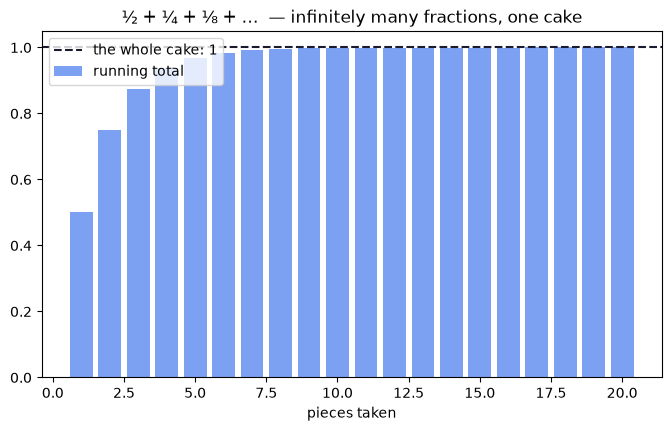

after 20 pieces: 0.9999990463256836 — short of 1 by 9.5367431640625e-07


In [6]:
n = np.arange(1, 21)                 # term numbers 1..20
terms = 1 / 2**n                     # 1/2, 1/4, 1/8, ...
running = np.cumsum(terms)           # cumsum = running total (a Σ in disguise — unit 0.6!)

plt.figure(figsize=(8, 4.5))
plt.bar(n, running, color="#2563eb", alpha=0.6, label="running total")
plt.axhline(1, color="#1a1a2e", linestyle="--", label="the whole cake: 1")
plt.xlabel("pieces taken")
plt.title("\u00bd + \u00bc + \u215b + \u2026  \u2014 infinitely many fractions, one cake")
plt.legend()
plt.show()

print("after 20 pieces:", running[-1], "\u2014 short of 1 by", 1 - running[-1])

An infinite sum with a finite answer. This exact idea — *geometric series* — sets the
noise schedules inside stable diffusion (Module 6), and that shortfall halving each step
is precisely how a well-trained loss curve behaves.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 0.5 — exponents & logarithms.*